## Import Library

In [ ]:
# Import library untuk load model, data, dan evaluasi
import platform
import psutil
import resource
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from statsmodels.stats.contingency_tables import mcnemar
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification


# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Model and Data Preparation

### SVM

In [ ]:
bundle_path_svm = '/content/drive/MyDrive/skripsi/svm_indobert/model/svm_linearsvc_data_2_2.pkl'

with open (bundle_path_svm, 'rb') as f:
  bundle_svm = pickle.load(f)

svm_model = bundle_svm['model']
svm_vec = bundle_svm['vectorizer']
svm_le = bundle_svm['label_encoder']

### IndoBERT

In [ ]:
save_dir = '/content/drive/MyDrive/skripsi/svm_indobert/model/indobert_data_2_2'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[INFO] Device: {device}')

# Load  Model & Tokenizer
indobert_model = AutoModelForSequenceClassification.from_pretrained(save_dir)
indobert_model.to(device)
indobert_model.eval()  # mode inference

indobert_tokenizer = AutoTokenizer.from_pretrained(save_dir)

with open(f'{save_dir}/le_bundle.pkl', 'rb') as f:
    bundle_indobert = pickle.load(f)

indobert_le = bundle_indobert['le']

[INFO] Device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
print("SVM label mapping:", list(svm_le.classes_))
print("IndoBERT label mapping:", list(indobert_le.classes_))

assert list(svm_le.classes_) == list(indobert_le.classes_), (
    "SVM and IndoBERT label mappings are inconsistent."
)

print("✓ Label mappings are consistent.")

SVM label mapping: [np.str_('Keterlambatan'), np.str_('Pelayanan'), np.str_('Kepadatan'), np.str_('Keamanan'), np.str_('Kebersihan')]
IndoBERT label mapping: [np.str_('Keterlambatan'), np.str_('Pelayanan'), np.str_('Kepadatan'), np.str_('Keamanan'), np.str_('Kebersihan')]
✓ Label mappings are consistent.


In [ ]:
def get_hardware_info():
    info = {
        'cpu': {
            'processor': platform.processor() or platform.machine(),
            'physical_cores': psutil.cpu_count(logical=False),
            'logical_cores': psutil.cpu_count(logical=True),
            'ram_gb': round(psutil.virtual_memory().total / (1024 ** 3), 2),
        },
        'gpu': {'available': False},
    }
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        info['gpu'] = {
            'available': True,
            'name': props.name,
            'total_memory_gb': round(props.total_memory / (1024 ** 3), 2),
            'cuda_version': torch.version.cuda,
        }
    return info


def print_hardware_info(info):
    print('Hardware Information')
    cpu = info['cpu']
    print(f"CPU : {cpu['processor']} "
          f"({cpu['physical_cores']} cores / {cpu['logical_cores']} threads), "
          f"{cpu['ram_gb']} GB RAM")
    if info['gpu']['available']:
        gpu = info['gpu']
        print(f"GPU : {gpu['name']}, {gpu['total_memory_gb']} GB VRAM, CUDA {gpu['cuda_version']}")
    else:
        print('GPU : Not available')


hardware_info = get_hardware_info()
print_hardware_info(hardware_info)

Hardware Information
CPU : x86_64 (1 cores / 2 threads), 12.67 GB RAM
GPU : Tesla T4, 14.56 GB VRAM, CUDA 12.8


In [ ]:
!nvidia-smi

Wed Aug 26 04:16:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             26W /   70W |     635MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### External Dataset

In [ ]:
df_ext = pd.read_csv(
    '/content/drive/MyDrive/skripsi/svm_indobert/data/final_data/2026_krl_complaints_preprocessed_4.csv'
)

In [ ]:
# Class Distribution (External Data)
dist_counts = df_ext['label'].value_counts()
dist_pct = dist_counts / dist_counts.sum() * 100

dist_table = pd.DataFrame({
    'Frekuensi': dist_counts,
    'Persentase (%)': dist_pct.round(2)
})

print('\nDistribusi Label (External Data):')
print(dist_table.to_string())


Distribusi Label (External Data):
               Frekuensi  Persentase (%)
label                                   
Keterlambatan        204           41.55
Pelayanan            125           25.46
Kepadatan            116           23.63
Keamanan              29            5.91
Kebersihan            17            3.46


## Inference Speed Benchmark

### SVM

In [ ]:
def benchmark_svm(texts, n_runs=5):
  texts = texts.tolist()
  n_samples = len(texts)

  def _run_once():
    # Start total end-to-end timing
    start_time = time.perf_counter()

    # TF-IDF transformation
    tokenize_start = time.perf_counter()
    x_tfidf = svm_vec.transform(texts)
    tokenize_time = time.perf_counter() - tokenize_start

    # Model inference
    infer_start = time.perf_counter()
    preds = svm_model.predict(x_tfidf)
    inference_time = time.perf_counter() - infer_start

    # End total timing
    total_time = time.perf_counter() - start_time

    peak_ram_gb = (
        resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        / (1024 ** 2)
    )

    return {
        'preds': preds,
        'total_time': total_time,
        'tokenize_time': tokenize_time,
        'inference_time': inference_time,
        'peak_ram_gb': peak_ram_gb
    }

  # Warm-Up
  print('\n[INFO] Performing warm-up...')
  warmup_texts = texts[:100]
  x_warmup = svm_vec.transform(warmup_texts)
  _ = svm_model.predict(x_warmup)

  # Repeated measurements
  print(f'[INFO] Starting benchmark ({n_runs} runs)...')
  runs = [_run_once() for _ in range(n_runs)]

  total_times = np.array([r['total_time'] for r in runs])
  peak_rams = np.array([r['peak_ram_gb'] for r in runs])
  tokenize_times = np.array([r['tokenize_time'] for r in runs])
  inference_times = np.array([r['inference_time'] for r in runs])
  throughputs = n_samples / total_times

  return {
      'n_samples': n_samples,
      'n_runs': n_runs,
      'svm_preds': runs[-1]['preds'], # prediksi deterministik
      'total_time_mean': total_times.mean(),
      'total_time_std': total_times.std(ddof=1) if n_runs > 1 else 0.0,
      'tokenize_time_mean': tokenize_times.mean(),
      'inference_time_mean': inference_times.mean(),
      'throughput_mean': throughputs.mean(),
      'throughput_std': throughputs.std(ddof=1) if n_runs > 1 else 0.0,
      'time_per_sample_mean': total_times.mean() / n_samples,
      'peak_ram_gb': peak_rams.max(),
      'hardware': 'CPU'
  }

### IndoBERT

In [ ]:
def benchmark_indobert(batch_size, texts, max_len=128, n_runs=5):
    texts = texts.tolist()
    n_samples = len(texts)

    def _run_once():
      if device.type == 'cuda':
          torch.cuda.reset_peak_memory_stats(device)
          torch.cuda.synchronize()

      all_preds = []
      tokenize_time = 0.0

      # Start total end-to-end timing
      start_time = time.perf_counter()

      for i in range(0, n_samples, batch_size):
          batch_texts = texts[i:i + batch_size]

          # Tokenization
          tokenize_start = time.perf_counter()

          encodings = indobert_tokenizer(
              batch_texts,
              padding=True,
              truncation=True,
              max_length=max_len,
              return_tensors='pt'
          )

          tokenize_time += time.perf_counter() - tokenize_start

          # Transfer input to device
          encodings = {
              k: v.to(device)
              for k, v in encodings.items()
          }

          # Model inference
          with torch.no_grad():
              outputs = indobert_model(**encodings)
              preds = torch.argmax(outputs.logits, dim=1)

          # Transfer predictions to CPU
          all_preds.extend(preds.cpu().numpy())

      # Ensure all CUDA operations are completed
      if device.type == 'cuda':
          torch.cuda.synchronize()

      # End total timing
      total_time = time.perf_counter() - start_time

      # Derived inference/pipeline time
      inference_time = total_time - tokenize_time

      peak_vram_gb = (
          torch.cuda.max_memory_allocated(device) / (1024 ** 3)
          if device.type == 'cuda'
          else 0.0
      )

      return {
          'preds': np.array(all_preds),
          'total_time': total_time,
          'tokenize_time': tokenize_time,
          'inference_time': inference_time,
          'peak_vram_gb': peak_vram_gb
      }

    # Warm-up
    print('\n[INFO] Performing warm-up...')
    for i in range(0, min(3 * batch_size, n_samples), batch_size):
        batch_texts = texts[i:i + batch_size]
        encodings = indobert_tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=max_len, return_tensors='pt'
        )
        encodings = {k: v.to(device) for k, v in encodings.items()}
        with torch.no_grad():
            _ = indobert_model(**encodings)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Repeated measurements
    print(f'[INFO] Starting benchmark ({n_runs} runs)...')
    runs = [_run_once() for _ in range(n_runs)]

    total_times = np.array([r['total_time'] for r in runs])
    tokenize_times = np.array([r['tokenize_time'] for r in runs])
    inference_times = np.array([r['inference_time'] for r in runs])
    throughputs = n_samples / total_times
    peak_vrams = np.array([r['peak_vram_gb'] for r in runs])

    return {
        'batch_size': batch_size,
        'n_samples': n_samples,
        'n_runs': n_runs,
        'indobert_preds': runs[-1]['preds'],  # prediksi deterministik, sama tiap run
        'total_time_mean': total_times.mean(),
        'total_time_std': total_times.std(ddof=1) if n_runs > 1 else 0.0,
        'tokenize_time_mean': tokenize_times.mean(),
        'inference_time_mean': inference_times.mean(),
        'throughput_mean': throughputs.mean(),
        'throughput_std': throughputs.std(ddof=1) if n_runs > 1 else 0.0,
        'time_per_sample_mean': total_times.mean() / n_samples,
        'peak_vram_gb': peak_vrams.max(),
    }

### Report

In [ ]:
def print_speed(result, model_name):
  print(f'\nInference Speed Benchmark - {model_name}')
  if 'batch_size' in result:
    print(f"Batch Size             : {result['batch_size']}")
  print(f"Samples                  : {result['n_samples']}")
  print(f"Runs                     : {result['n_runs']}")
  print(f"Tokenize time (avg)      : {result['tokenize_time_mean']:.4f} sec")
  print(f"Inference time (avg)     : {result['inference_time_mean']:.4f} sec")
  print(f"Total time               : {result['total_time_mean']:.4f} sec ± {result['total_time_std']:.4f} sec")
  print(f"Time per sample          : {result['time_per_sample_mean']:.6f} sec")
  print(f"Throughput               : {result['throughput_mean']:.2f} ± {result['throughput_std']:.2f} samples/sec")
  if 'peak_vram_gb' in result:
        print(f"Peak VRAM          : {result['peak_vram_gb']:.2f} GB")

In [ ]:
def report_and_plot (y_true, y_pred, label_encoder, title_suffix=''):
  report_dict = classification_report(
      y_true, y_pred, target_names=label_encoder.classes_, output_dict=True
  )

  print(f'\nClassification Report - {title_suffix}')
  print(classification_report (
      y_true, y_pred, target_names=label_encoder.classes_, digits=4
  ))

  plt.figure(figsize=(7, 5))
  sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True, fmt='d', cmap='Oranges',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
  )

  plt.title(f'Confusion Matrix — {title_suffix}')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.tight_layout()
  plt.show()

  print('\nMetrics Summary')
  print(f"  Accuracy        : {report_dict['accuracy']:.4f}")
  print(f"  Macro F1        : {report_dict['macro avg']['f1-score']:.4f}")
  print(f"  Weighted F1     : {report_dict['weighted avg']['f1-score']:.4f}")
  print(f"  Macro Precision : {report_dict['macro avg']['precision']:.4f}")
  print(f"  Macro Recall    : {report_dict['macro avg']['recall']:.4f}")

  return report_dict

## Bootstrap 95% CI

In [ ]:
def bootstrap_degradation(
    y_true,
    y_pred,
    internal_score,
    n_bootstrap=5000,
    confidence_level=0.95,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    n_samples = len(y_true)
    degradation_scores = []

    for _ in range(n_bootstrap):

        indices = rng.integers(
            0,
            n_samples,
            size=n_samples
        )

        y_true_sample = y_true[indices]
        y_pred_sample = y_pred[indices]

        external_score = f1_score(
            y_true_sample,
            y_pred_sample,
            average='macro'
        )

        degradation = external_score - internal_score

        degradation_scores.append(degradation)

    degradation_scores = np.array(degradation_scores)

    alpha = 1 - confidence_level

    lower = np.percentile(
        degradation_scores,
        100 * (alpha / 2)
    )

    upper = np.percentile(
        degradation_scores,
        100 * (1 - alpha / 2)
    )

    return {
        'estimate': f1_score(
            y_true,
            y_pred,
            average='macro'
        ) - internal_score,
        'lower': lower,
        'upper': upper
    }

In [ ]:
def bootstrap_degradation_difference(
    y_true_external,
    y_pred_svm,
    internal_f1_svm,
    y_pred_indobert,
    internal_f1_indobert,
    n_bootstrap=5000,
    confidence_level=0.95,
    random_state=42
):
    """
    Paired bootstrap CI for the difference in temporal degradation.

    Degradation is defined as:
         external F1 - internal F1

    Difference is defined as:
        SVM degradation - IndoBERT degradation
    """

    rng = np.random.default_rng(random_state)

    y_true_external = np.asarray(y_true_external)
    y_pred_svm = np.asarray(y_pred_svm)
    y_pred_indobert = np.asarray(y_pred_indobert)

    n_samples = len(y_true_external)

    # --------------------------------------------------
    # Validate inputs
    # --------------------------------------------------

    assert len(y_pred_svm) == n_samples
    assert len(y_pred_indobert) == n_samples

    # --------------------------------------------------
    # Observed external F1
    # --------------------------------------------------

    external_f1_svm = f1_score(
        y_true_external,
        y_pred_svm,
        average='macro'
    )

    external_f1_indobert = f1_score(
        y_true_external,
        y_pred_indobert,
        average='macro'
    )

    # --------------------------------------------------
    # Observed degradation
    # --------------------------------------------------

    degradation_svm = (
        external_f1_svm - internal_f1_svm
    )

    degradation_indobert = (
       external_f1_indobert - internal_f1_indobert
    )

    observed_difference = (
        degradation_svm - degradation_indobert
    )

    # --------------------------------------------------
    # Paired bootstrap
    # --------------------------------------------------

    bootstrap_differences = np.empty(n_bootstrap)

    for i in range(n_bootstrap):

        indices = rng.integers(
            0,
            n_samples,
            size=n_samples
        )

        # Same bootstrap indices for both models
        y_true_boot = y_true_external[indices]
        svm_pred_boot = y_pred_svm[indices]
        indobert_pred_boot = y_pred_indobert[indices]

        f1_svm_boot = f1_score(
            y_true_boot,
            svm_pred_boot,
            average='macro'
        )

        f1_indobert_boot = f1_score(
            y_true_boot,
            indobert_pred_boot,
            average='macro'
        )

        degradation_svm_boot = (
            f1_svm_boot - internal_f1_svm
        )

        degradation_indobert_boot = (
            f1_indobert_boot - internal_f1_indobert
        )

        bootstrap_differences[i] = (
            degradation_svm_boot
            - degradation_indobert_boot
        )

    # --------------------------------------------------
    # Confidence interval
    # --------------------------------------------------

    alpha = 1 - confidence_level

    lower = np.percentile(
        bootstrap_differences,
        100 * (alpha / 2)
    )

    upper = np.percentile(
        bootstrap_differences,
        100 * (1 - alpha / 2)
    )

    return {
        'svm_external_f1': external_f1_svm,
        'indobert_external_f1': external_f1_indobert,

        'svm_degradation': degradation_svm,
        'indobert_degradation': degradation_indobert,

        'difference': observed_difference,

        'ci_lower': lower,
        'ci_upper': upper,

        'bootstrap_distribution': bootstrap_differences
    }

In [ ]:
def permutation_test_degradation_difference(
    y_true_external,
    y_pred_svm,
    internal_f1_svm,
    y_pred_indobert,
    internal_f1_indobert,
    n_permutations=5000,
    random_state=42
):
    """
    Paired permutation test for difference in temporal degradation.

    Degradation:
        external F1 - internal F1

    Test:
        SVM degradation - IndoBERT degradation = 0
    """

    rng = np.random.default_rng(random_state)

    y_true_external = np.asarray(y_true_external)
    y_pred_svm = np.asarray(y_pred_svm)
    y_pred_indobert = np.asarray(y_pred_indobert)

    n_samples = len(y_true_external)

    # --------------------------------------------------
    # Validate inputs
    # --------------------------------------------------

    assert len(y_pred_svm) == n_samples
    assert len(y_pred_indobert) == n_samples

    # --------------------------------------------------
    # Observed degradation difference
    # --------------------------------------------------

    external_f1_svm = f1_score(
        y_true_external,
        y_pred_svm,
        average='macro'
    )

    external_f1_indobert = f1_score(
        y_true_external,
        y_pred_indobert,
        average='macro'
    )

    degradation_svm = (
        external_f1_svm - internal_f1_svm
    )

    degradation_indobert = (
        external_f1_indobert - internal_f1_indobert
    )

    observed_difference = (
        degradation_svm - degradation_indobert
    )

    # --------------------------------------------------
    # Permutation distribution
    # --------------------------------------------------

    permutation_differences = np.empty(n_permutations)

    for i in range(n_permutations):

        # Randomly swap the two model predictions
        # within each paired observation
        swap = rng.random(n_samples) < 0.5

        perm_svm = y_pred_svm.copy()
        perm_indobert = y_pred_indobert.copy()

        temp = perm_svm[swap].copy()

        perm_svm[swap] = perm_indobert[swap]
        perm_indobert[swap] = temp

        # Calculate external F1 after permutation
        perm_f1_svm = f1_score(
            y_true_external,
            perm_svm,
            average='macro'
        )

        perm_f1_indobert = f1_score(
            y_true_external,
            perm_indobert,
            average='macro'
        )

        # Difference in degradation
        perm_degradation_svm = (
            perm_f1_svm - internal_f1_svm
        )

        perm_degradation_indobert = (
            perm_f1_indobert - internal_f1_indobert
        )

        permutation_differences[i] = (
            perm_degradation_svm
            - perm_degradation_indobert
        )

    # --------------------------------------------------
    # Two-sided permutation p-value
    # --------------------------------------------------

    p_value = (
        np.sum(
            np.abs(permutation_differences)
            >= abs(observed_difference)
        ) + 1
    ) / (n_permutations + 1)

    return {
        'difference': observed_difference,
        'p_value': p_value,
        'permutation_distribution': permutation_differences
    }

## Running

### Inference


[INFO] Performing warm-up...
[INFO] Starting benchmark (5 runs)...

Inference Speed Benchmark - SVM
Samples                  : 491
Runs                     : 5
Tokenize time (avg)      : 0.0118 sec
Inference time (avg)     : 0.0003 sec
Total time               : 0.0122 sec ± 0.0022 sec
Time per sample          : 0.000025 sec
Throughput               : 41216.12 ± 6108.05 samples/sec

Classification Report - SVM Inference
               precision    recall  f1-score   support

Keterlambatan     0.8718    0.8333    0.8521       204
    Pelayanan     0.7304    0.6720    0.7000       125
    Kepadatan     0.7519    0.8621    0.8032       116
     Keamanan     0.4828    0.4828    0.4828        29
   Kebersihan     0.7368    0.8235    0.7778        17

     accuracy                         0.7780       491
    macro avg     0.7147    0.7347    0.7232       491
 weighted avg     0.7798    0.7780    0.7775       491



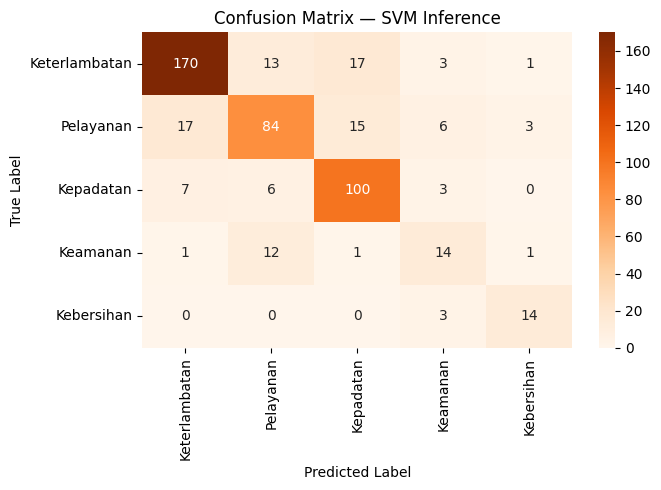


Metrics Summary
  Accuracy        : 0.7780
  Macro F1        : 0.7232
  Weighted F1     : 0.7775
  Macro Precision : 0.7147
  Macro Recall    : 0.7347


In [ ]:
# SVM
result_svm = benchmark_svm(df_ext['text_svm'])
print_speed(result_svm, 'SVM')

y_true_svm = svm_le.transform(df_ext['label'])
svm_preds = result_svm['svm_preds']
svm_report_dict = report_and_plot(y_true_svm, svm_preds, svm_le, 'SVM Inference')


[INFO] Performing warm-up...
[INFO] Starting benchmark (5 runs)...

Inference Speed Benchmark - IndoBERT
Batch Size             : 1
Samples                  : 491
Runs                     : 5
Tokenize time (avg)      : 0.1638 sec
Inference time (avg)     : 4.4644 sec
Total time               : 4.6282 sec ± 0.4474 sec
Time per sample          : 0.009426 sec
Throughput               : 106.87 ± 10.07 samples/sec
Peak VRAM          : 0.47 GB

Classification Report - IndoBERT Inference Batch 1
               precision    recall  f1-score   support

Keterlambatan     0.9011    0.8039    0.8497       204
    Pelayanan     0.7670    0.6320    0.6930       125
    Kepadatan     0.6957    0.8276    0.7559       116
     Keamanan     0.3958    0.6552    0.4935        29
   Kebersihan     0.6500    0.7647    0.7027        17

     accuracy                         0.7556       491
    macro avg     0.6819    0.7367    0.6990       491
 weighted avg     0.7799    0.7556    0.7615       491



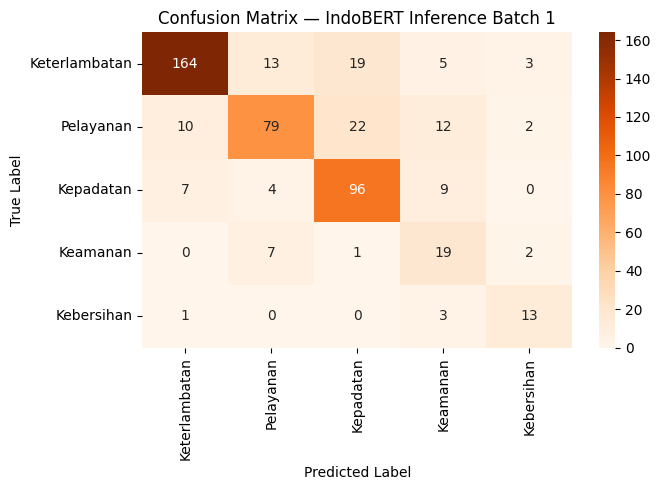


Metrics Summary
  Accuracy        : 0.7556
  Macro F1        : 0.6990
  Weighted F1     : 0.7615
  Macro Precision : 0.6819
  Macro Recall    : 0.7367

[INFO] Performing warm-up...
[INFO] Starting benchmark (5 runs)...

Inference Speed Benchmark - IndoBERT
Batch Size             : 16
Samples                  : 491
Runs                     : 5
Tokenize time (avg)      : 0.1494 sec
Inference time (avg)     : 1.3779 sec
Total time               : 1.5272 sec ± 0.1407 sec
Time per sample          : 0.003110 sec
Throughput               : 323.46 ± 26.74 samples/sec
Peak VRAM          : 0.51 GB

Classification Report - IndoBERT Inference Batch 16
               precision    recall  f1-score   support

Keterlambatan     0.9011    0.8039    0.8497       204
    Pelayanan     0.7670    0.6320    0.6930       125
    Kepadatan     0.6957    0.8276    0.7559       116
     Keamanan     0.3958    0.6552    0.4935        29
   Kebersihan     0.6500    0.7647    0.7027        17

     accuracy      

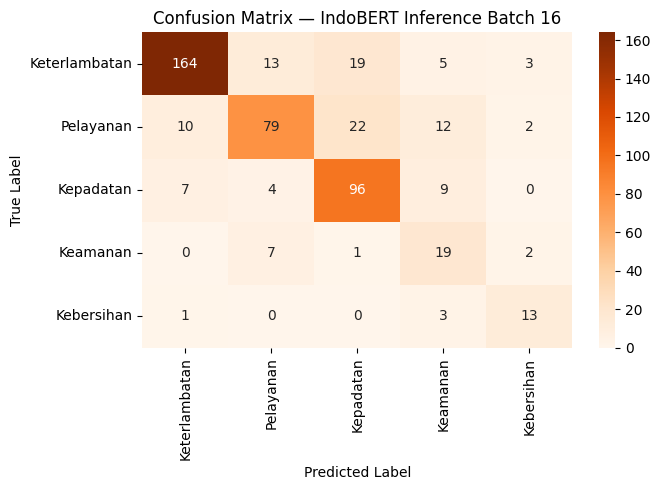


Metrics Summary
  Accuracy        : 0.7556
  Macro F1        : 0.6990
  Weighted F1     : 0.7615
  Macro Precision : 0.6819
  Macro Recall    : 0.7367

[INFO] Performing warm-up...
[INFO] Starting benchmark (5 runs)...

Inference Speed Benchmark - IndoBERT
Batch Size             : 32
Samples                  : 491
Runs                     : 5
Tokenize time (avg)      : 0.1158 sec
Inference time (avg)     : 1.3804 sec
Total time               : 1.4962 sec ± 0.0715 sec
Time per sample          : 0.003047 sec
Throughput               : 328.72 ± 14.80 samples/sec
Peak VRAM          : 0.54 GB

Classification Report - IndoBERT Inference Batch 32
               precision    recall  f1-score   support

Keterlambatan     0.9011    0.8039    0.8497       204
    Pelayanan     0.7670    0.6320    0.6930       125
    Kepadatan     0.6957    0.8276    0.7559       116
     Keamanan     0.3958    0.6552    0.4935        29
   Kebersihan     0.6500    0.7647    0.7027        17

     accuracy      

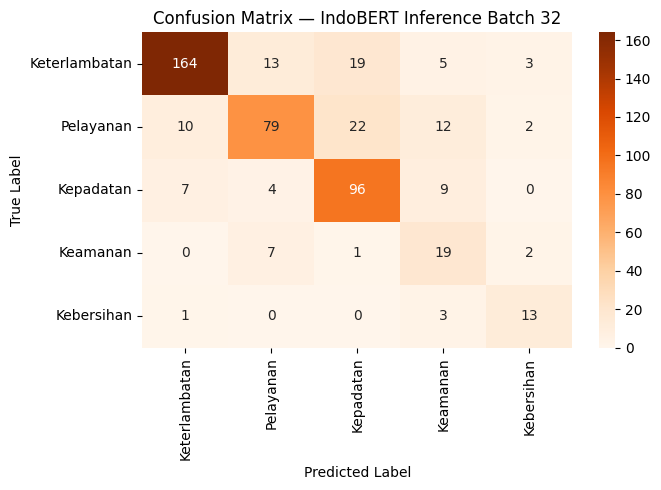


Metrics Summary
  Accuracy        : 0.7556
  Macro F1        : 0.6990
  Weighted F1     : 0.7615
  Macro Precision : 0.6819
  Macro Recall    : 0.7367

[INFO] Performing warm-up...
[INFO] Starting benchmark (5 runs)...

Inference Speed Benchmark - IndoBERT
Batch Size             : 64
Samples                  : 491
Runs                     : 5
Tokenize time (avg)      : 0.1061 sec
Inference time (avg)     : 1.3544 sec
Total time               : 1.4605 sec ± 0.0185 sec
Time per sample          : 0.002975 sec
Throughput               : 336.23 ± 4.24 samples/sec
Peak VRAM          : 0.60 GB

Classification Report - IndoBERT Inference Batch 64
               precision    recall  f1-score   support

Keterlambatan     0.9011    0.8039    0.8497       204
    Pelayanan     0.7670    0.6320    0.6930       125
    Kepadatan     0.6957    0.8276    0.7559       116
     Keamanan     0.3958    0.6552    0.4935        29
   Kebersihan     0.6500    0.7647    0.7027        17

     accuracy       

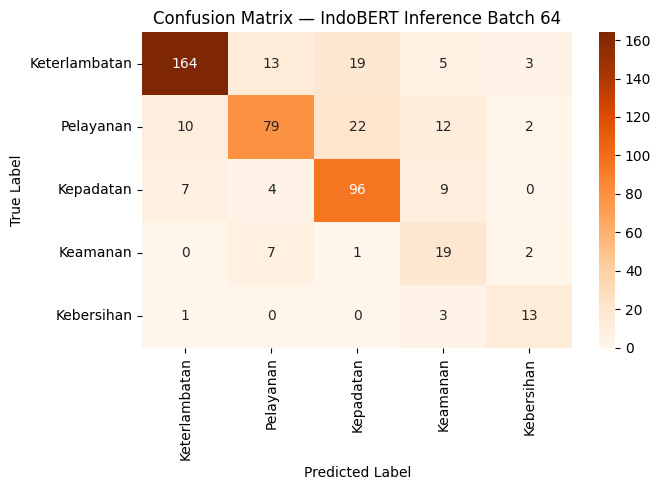


Metrics Summary
  Accuracy        : 0.7556
  Macro F1        : 0.6990
  Weighted F1     : 0.7615
  Macro Precision : 0.6819
  Macro Recall    : 0.7367


In [ ]:
y_true_indobert = indobert_le.transform(df_ext['label'])

indobert_results = {}

for bs in [1, 16, 32, 64]:
  res = benchmark_indobert(bs, df_ext['text_bert'])
  print_speed(res, 'IndoBERT')
  report = report_and_plot(
      y_true_indobert, res['indobert_preds'], indobert_le, f'IndoBERT Inference Batch {bs}'
  )
  indobert_results[bs] = {'result': res, 'report': report}

indobert_preds = indobert_results[16]['result']['indobert_preds']

### Reconstruct

In [ ]:
# Load dataset dari file CSV
path = '/content/drive/MyDrive/skripsi/svm_indobert/data/final_data/krl_complaints_preprocessed_4.csv'
df = pd.read_csv(path)

In [ ]:
# Dictionary Label untuk mapping label kategori ke angka
label_map = {
    'Keterlambatan' : 0,
    'Pelayanan'     : 1,
    'Kepadatan'     : 2,
    'Keamanan'      : 3,
    'Kebersihan'    : 4
}

# Encode kolom 'label' menjadi numerik sesuai label_map
df['label_encoded'] = df['label'].map(label_map)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# SVM
X_train_svm, X_temp_svm, y_train_svm, y_temp_svm = train_test_split(
    df['text_svm'],
    df['label_encoded'],
    test_size=0.30,
    stratify=df['label_encoded'],
    random_state=42
)

X_val_svm, X_test_svm, y_val_svm, y_test_svm = train_test_split(
    X_temp_svm,
    y_temp_svm,
    test_size=0.50,
    stratify=y_temp_svm,
    random_state=42
)

In [ ]:
X_test_svm_vec = svm_vec.transform(X_test_svm)

y_pred_internal_svm = svm_model.predict(X_test_svm_vec)

y_true_internal_svm = y_test_svm.to_numpy()

print(len(y_true_internal_svm))
print(len(y_pred_internal_svm))

738
738


In [ ]:
svm_internal_f1 = f1_score(
    y_true_internal_svm,
    y_pred_internal_svm,
    average='macro'
)

f1_saved_svm = bundle_svm['test_report']['macro avg']['f1-score']

print("\nInternal Macro F1:")
print("Reconstructed :", svm_internal_f1)
print("Saved report  :", f1_saved_svm)
print("Difference    :", abs(svm_internal_f1 - f1_saved_svm))


Internal Macro F1:
Reconstructed : 0.7645898035618653
Saved report  : 0.7645898035618653
Difference    : 0.0


In [ ]:
# IndoBERT
X_train_bert, X_temp_bert, y_train_bert, y_temp_bert = train_test_split(
    df['text_bert'],
    df['label_encoded'],
    test_size=0.30,
    stratify=df['label_encoded'],
    random_state=42
)

X_val_bert, X_test_bert, y_val_bert, y_test_bert = train_test_split(
    X_temp_bert,
    y_temp_bert,
    test_size=0.50,
    stratify=y_temp_bert,
    random_state=42
)

In [ ]:
BATCH_SIZE = 16
MAX_LEN    = 128

In [ ]:
texts = X_test_bert.tolist()
all_preds = []

print("\n[INFO] Memulai inference IndoBERT pada internal test set...")

for i in range(0, len(texts), BATCH_SIZE):

    batch_texts = texts[i:i + BATCH_SIZE]

    # Tokenisasi batch
    encodings = indobert_tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    # Pindahkan input ke device yang sama dengan model
    encodings = {
        k: v.to(device)
        for k, v in encodings.items()
    }

    # Inference tanpa menghitung gradient
    with torch.inference_mode():
        outputs = indobert_model(**encodings)
        logits = outputs.logits

        # Ambil kelas dengan probabilitas/logit terbesar
        preds = torch.argmax(logits, dim=1)

    # Pindahkan prediksi ke CPU
    all_preds.extend(preds.cpu().numpy())

# Convert ke NumPy array
y_pred_internal_bert = np.array(all_preds)

print(f"[INFO] Jumlah prediksi: {len(y_pred_internal_bert)}")


[INFO] Memulai inference IndoBERT pada internal test set...
[INFO] Jumlah prediksi: 738


In [ ]:
y_true_internal_bert = y_test_bert.to_numpy()

indobert_internal_f1 = f1_score(
    y_true_internal_bert,
    y_pred_internal_bert,
    average='macro'
)

f1_saved_indobert = bundle_indobert['test_report']['macro avg']['f1-score']

print("Internal Macro F1:")
print("Reconstructed :", indobert_internal_f1)
print("Saved report  :", f1_saved_indobert)
print("Difference    :", abs(indobert_internal_f1 - f1_saved_indobert))

Internal Macro F1:
Reconstructed : 0.7707078137973654
Saved report  : 0.7707078137973654
Difference    : 0.0


### Bootstrap 95% CI for External Degradation

In [ ]:
svm_deg_bootstrap = bootstrap_degradation(
    y_true_svm,
    svm_preds,
    internal_score=svm_internal_f1,
    n_bootstrap=5000,
    random_state=42
)

indobert_deg_bootstrap = bootstrap_degradation(
    y_true_indobert,
    indobert_preds,
    internal_score=indobert_internal_f1,
    n_bootstrap=5000,
    random_state=42
)

In [ ]:
print('\nBootstrap 95% CI for External Degradation')

print(
    f"SVM      : {svm_deg_bootstrap['estimate']:.4f}"
    f"[{svm_deg_bootstrap['lower']:.4f}, {svm_deg_bootstrap['upper']:.4f}]"
)

print(
    f"IndoBERT : {indobert_deg_bootstrap['estimate']:.4f}"
    f"[{indobert_deg_bootstrap['lower']:.4f}, {indobert_deg_bootstrap['upper']:.4f}]"
)


Bootstrap 95% CI for External Degradation
SVM      : -0.0414[-0.1002, 0.0098]
IndoBERT : -0.0717[-0.1297, -0.0204]


In [ ]:
diff_bootstrap = bootstrap_degradation_difference(
    y_true_svm,
    svm_preds,
    svm_internal_f1,
    indobert_preds,
    indobert_internal_f1,
    n_bootstrap=5000,
    random_state=42
)

In [ ]:
print("\nDifference of Temporal Degradation")

print(
    f"SVM degradation: "
    f"{diff_bootstrap['svm_degradation']:.4f}"
)

print(
    f"IndoBERT degradation: "
    f"{diff_bootstrap['indobert_degradation']:.4f}"
)

print(
    f"Difference (SVM - IndoBERT): "
    f"{diff_bootstrap['difference']:.4f}"
)

print(
    f"95% Bootstrap CI: "
    f"[{diff_bootstrap['ci_lower']:.4f}, "
    f"{diff_bootstrap['ci_upper']:.4f}]"
)


Difference of Temporal Degradation
SVM degradation: -0.0414
IndoBERT degradation: -0.0717
Difference (SVM - IndoBERT): 0.0303
95% Bootstrap CI: [-0.0290, 0.0898]


In [ ]:
permutation_result = permutation_test_degradation_difference(
    y_true_svm,
    svm_preds,
    svm_internal_f1,
    indobert_preds,
    indobert_internal_f1,
    n_permutations=5000,
    random_state=42
)

In [ ]:
print("\nPermutation Test: Difference of Degradation")

print(
    f"Observed difference: "
    f"{permutation_result['difference']:.4f}"
)

print(
    f"p-value: "
    f"{permutation_result['p_value']:.4f}"
)


Permutation Test: Difference of Degradation
Observed difference: 0.0303
p-value: 0.3153


### McNemar Test

In [ ]:
# Periksa prediksi masing-masing model
svm_correct = (svm_preds == y_true_svm)
indobert_correct = (indobert_preds == y_true_indobert)

# Tabel kontingensi 2x2
table = np.array([
    [
        np.sum(svm_correct & indobert_correct),
        np.sum(svm_correct & ~indobert_correct)
    ],
    [
        np.sum(~svm_correct & indobert_correct),
        np.sum(~svm_correct & ~indobert_correct)
    ]
])

print('McNemar contingency table:')
print(table)

# McNemar's test
result = mcnemar(table,exact=True)

print("\nMcNemar's Test")
print(f'Statistic : {result.statistic}')
print(f'p-value   : {result.pvalue}')

McNemar contingency table:
[[338  44]
 [ 33  76]]

McNemar's Test
Statistic : 33.0
p-value   : 0.2543046661477
